[INFO] 2000 (Baseline): 877680 rows after filtering
[INFO] SSP245 - 2050: 467776 rows after filtering
[INFO] SSP245 - 2090: 584640 rows after filtering
[INFO] SSP585 - 2050: 584720 rows after filtering
[INFO] SSP585 - 2090: 584640 rows after filtering
✅ Saved Excel file : C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim phenology projection\figure\Phenology_Results_DAS.xlsx


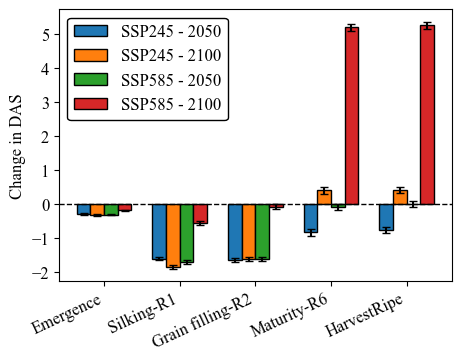

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'font.family': 'Times New Roman'
})

excel_files = {
    "2000 (Baseline)": r"C:/Users/Amine/workspace/morocco_maize/phenology projection-APSIM/excel/fichier_combineeeee.csv",
    "SSP245 - 2050":   r"C:/Users/Amine/workspace/morocco_maize/phenology projection-APSIM/excel/fichier_combineeeee-2024-2063.csv",
    "SSP245 - 2090":   r"C:/Users/Amine/workspace/morocco_maize/phenology projection-APSIM/excel/fichier_combineeeee-2060-2090.csv",
    "SSP585 - 2050":   r"C:/Users/Amine/workspace/morocco_maize/phenology projection-APSIM/excel/fichier_combineeeee-2024-2063-SSP585.csv",
    "SSP585 - 2090":   r"C:/Users/Amine/workspace/morocco_maize/phenology projection-APSIM/excel/fichier_combineeeee-2060-2090-SSP585.csv"
}

output_path = r"C:\Users\Amine\workspace\morocco_maize\APSIM tout les code et figure\apsim phenology projection\figure"

os.makedirs(output_path, exist_ok=True)

allowed_models = ["MIROC6", "CNRM-CM6-1", "IPSL-CM6A-LR", "INM-CM5-0", "NESM3"]

periods = {
    "2000 (Baseline)": list(range(1985, 2015)),
    "SSP245 - 2050":   list(range(2041, 2061)),
    "SSP245 - 2090":   list(range(2081, 2101)),
    "SSP585 - 2050":   list(range(2041, 2061)),
    "SSP585 - 2090":   list(range(2081, 2101))
}

# Noms réels présents dans les données
phenology_stages = ['Emergence', 'Flowering', 'StartGrainFill', 'Maturity', 'HarvestRipe']

# Noms à afficher sur l'axe X
stage_display_labels = {
    'Emergence': 'Emergence',
    'Flowering': 'Silking-R1',
    'StartGrainFill': 'Grain filling-R2',
    'Maturity': 'Maturity-R6',
    'HarvestRipe': 'HarvestRipe'
}

# Noms à afficher dans la légende
scenario_display_labels = {
    'SSP245 - 2050': 'SSP245 - 2050',
    'SSP245 - 2090': 'SSP245 - 2100',
    'SSP585 - 2050': 'SSP585 - 2050',
    'SSP585 - 2090': 'SSP585 - 2100'
}

PALETTE = {
    'SSP245 - 2050': '#1f77b4',
    'SSP245 - 2090': '#ff7f0e',
    'SSP585 - 2050': '#2ca02c',
    'SSP585 - 2090': '#d62728',
}


def standard_error(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors='coerce').dropna()
    n = len(s)
    if n <= 1:
        return np.nan
    return s.std(ddof=1) / np.sqrt(n)


def split_db_file(series: pd.Series) -> pd.DataFrame:
    """
    Parsing robuste de 'DB File'.

    Accepte par exemple :
    - B1_CNRM-CM6-1_ssp585
    - B1_CNRM-CM6-1
    - CNRM-CM6-1
    - valeurs manquantes

    Retourne toujours 3 colonnes : Treatment, Model, ScenarioTag
    """
    s = series.fillna('').astype(str).str.strip()

    parts = s.str.split('_', n=2, expand=True)

    # Garantir 3 colonnes même si certaines lignes ont moins de séparateurs "_"
    for col in range(3):
        if col not in parts.columns:
            parts[col] = ''

    parts = parts[[0, 1, 2]].copy()
    parts.columns = ['Treatment', 'Model', 'ScenarioTag']

    # Cas sans "_": on suppose que la valeur correspond au modèle
    mask_no_underscore = ~s.str.contains('_', regex=False)
    parts.loc[mask_no_underscore, 'Model'] = s[mask_no_underscore].values
    parts.loc[mask_no_underscore, 'Treatment'] = 'Unknown'
    parts.loc[mask_no_underscore, 'ScenarioTag'] = ''

    parts['Treatment'] = parts['Treatment'].replace('', 'Unknown')
    parts['Model'] = parts['Model'].replace('', 'Unknown')
    parts['ScenarioTag'] = parts['ScenarioTag'].fillna('')

    return parts


def load_and_prepare(file_path: str, scenario: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    required_cols = ['Clock.Today', 'Maize.Phenology.CurrentStageName']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Colonne obligatoire absente: {col}")

    df['Clock.Today'] = pd.to_datetime(df['Clock.Today'], errors='coerce')
    df['Year'] = df['Clock.Today'].dt.year

    if 'DB File' in df.columns:
        parsed = split_db_file(df['DB File'])
        df['Treatment'] = parsed['Treatment']
        df['Model'] = parsed['Model']
        df['ScenarioTag'] = parsed['ScenarioTag']
    else:
        df['Treatment'] = 'Unknown'
        df['Model'] = 'Unknown'
        df['ScenarioTag'] = ''

    df['Sowing'] = 'ref'

    df = df[
        df['Model'].isin(allowed_models) &
        df['Year'].isin(periods[scenario])
    ].copy()

    das_candidates = [
        'Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1',
        'Clock.Today.DayOfYear-Maize.SowingDate.DayOfYear+1,Clock.Today'
    ]
    das_col = next((c for c in das_candidates if c in df.columns), None)

    if das_col is not None:
        df['DAS'] = pd.to_numeric(df[das_col], errors='coerce')
    else:
        if 'Maize.SowingDate.DayOfYear' not in df.columns:
            raise ValueError(
                "Impossible de calculer DAS : aucune colonne DAS candidate trouvée "
                "et 'Maize.SowingDate.DayOfYear' est absente."
            )
        df['Clock.Today.DayOfYear'] = df['Clock.Today'].dt.dayofyear
        df['DAS'] = (
            pd.to_numeric(df['Clock.Today.DayOfYear'], errors='coerce')
            - pd.to_numeric(df['Maize.SowingDate.DayOfYear'], errors='coerce')
            + 1
        )

    df['DAS'] = pd.to_numeric(df['DAS'], errors='coerce')
    df['Maize.Phenology.CurrentStageName'] = (
        df['Maize.Phenology.CurrentStageName'].astype(str).str.strip()
    )

    df = df.dropna(subset=['Year', 'DAS', 'Treatment', 'Model']).copy()

    print(f"[INFO] {scenario}: {len(df)} rows after filtering")
    return df


def stage_stats(df: pd.DataFrame, stage: str):
    df_stage = df[df['Maize.Phenology.CurrentStageName'] == stage].copy()

    if df_stage.empty:
        stats = pd.DataFrame({
            'Stage': [stage],
            'Mean': [np.nan],
            'Std': [np.nan],
            'SE': [np.nan],
            'N': [0]
        })
        details = pd.DataFrame(columns=['Year', 'Treatment', 'Sowing', 'Model', 'DAS'])
        return stats, details

    df_stage.sort_values(['Treatment', 'Year', 'Model', 'DAS'], inplace=True)
    df_unique = df_stage.drop_duplicates(
        subset=['Treatment', 'Year', 'Model'],
        keep='first'
    ).copy()

    das = pd.to_numeric(df_unique['DAS'], errors='coerce').dropna()
    n = len(das)

    stats = pd.DataFrame({
        'Stage': [stage],
        'Mean': [das.mean() if n > 0 else np.nan],
        'Std': [das.std(ddof=1) if n > 1 else np.nan],
        'SE': [standard_error(das)],
        'N': [n]
    })

    details = df_unique[['Year', 'Treatment', 'Sowing', 'Model', 'DAS']].copy()
    return stats, details


# =========================
# Calculs statistiques
# =========================
all_stats = []
all_details = []

for scenario, f in excel_files.items():
    df = load_and_prepare(f, scenario)
    scen_stats = []

    for st in phenology_stages:
        s, d = stage_stats(df, st)
        s['Scenario'] = scenario
        d['Stage'] = st
        d['Scenario'] = scenario
        scen_stats.append(s)
        all_details.append(d)

    all_stats.append(pd.concat(scen_stats, ignore_index=True))

stats_df = pd.concat(all_stats, ignore_index=True)
detail_df = pd.concat(all_details, ignore_index=True)

mean_df = stats_df.pivot(index='Stage', columns='Scenario', values='Mean').reset_index()
std_df  = stats_df.pivot(index='Stage', columns='Scenario', values='Std').reset_index()
se_df   = stats_df.pivot(index='Stage', columns='Scenario', values='SE').reset_index()
n_df    = stats_df.pivot(index='Stage', columns='Scenario', values='N').reset_index()

mean_df = mean_df.set_index('Stage').reindex(phenology_stages).reset_index()
std_df  = std_df.set_index('Stage').reindex(phenology_stages).reset_index()
se_df   = se_df.set_index('Stage').reindex(phenology_stages).reset_index()
n_df    = n_df.set_index('Stage').reindex(phenology_stages).reset_index()

diff_cols = {}
diff_se_cols = {}
baseline_name = '2000 (Baseline)'
future_scenarios = ['SSP245 - 2050', 'SSP245 - 2090', 'SSP585 - 2050', 'SSP585 - 2090']

if baseline_name not in mean_df.columns:
    raise ValueError("La baseline '2000 (Baseline)' est absente des résultats.")

for s in future_scenarios:
    if s in mean_df.columns:
        diff_col = f'Diff_{s}_vs_2000'
        diff_se_col = f'SE_{s}_vs_2000'

        mean_df[diff_col] = mean_df[s] - mean_df[baseline_name]

        se_future = pd.to_numeric(se_df[s], errors='coerce')
        se_base = pd.to_numeric(se_df[baseline_name], errors='coerce')
        se_df[diff_se_col] = np.sqrt(se_future**2 + se_base**2)

        diff_cols[s] = diff_col
        diff_se_cols[s] = diff_se_col


# =========================
# Sauvegarde Excel
# =========================
out_xlsx = os.path.join(output_path, 'Phenology_Results_DAS.xlsx')

with pd.ExcelWriter(out_xlsx, engine='xlsxwriter') as writer:
    stats_df.to_excel(writer, sheet_name='Stage_Stats_Long', index=False)
    mean_df.to_excel(writer, sheet_name='Stage_Mean', index=False)
    std_df.to_excel(writer, sheet_name='Stage_Std', index=False)
    se_df.to_excel(writer, sheet_name='Stage_SE', index=False)
    n_df.to_excel(writer, sheet_name='Stage_N', index=False)
    detail_df.to_excel(writer, sheet_name='Detailed_ref_only', index=False)

print(f"✅ Saved Excel file : {out_xlsx}")


# =========================
# Graphique
# =========================
x = np.arange(len(phenology_stages))
scenarios_to_plot = [s for s in future_scenarios if s in diff_cols]
n_scen = len(scenarios_to_plot)

if n_scen == 0:
    raise ValueError("Aucun scénario futur disponible pour le graphique.")

bar_w = 0.18
offsets = (np.arange(n_scen) - (n_scen - 1) / 2) * bar_w

fig, ax = plt.subplots(figsize=(4.5,3.5), constrained_layout=True)

for i, scenario in enumerate(scenarios_to_plot):
    diff_col = diff_cols[scenario]
    err_col = diff_se_cols[scenario]

    y = pd.to_numeric(mean_df[diff_col], errors='coerce')
    yerr = pd.to_numeric(se_df[err_col], errors='coerce').fillna(0)

    ax.bar(
        x + offsets[i],
        y,
        yerr=yerr,
        width=bar_w,
        label=scenario_display_labels.get(scenario, scenario),
        color=PALETTE.get(scenario, None),
        edgecolor='black',
        capsize=3
    )

ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xticks(x)
ax.set_xticklabels(
    [stage_display_labels.get(stage, stage) for stage in phenology_stages],
    rotation=25,
    ha="right"
)
ax.set_ylabel('Change in DAS')
# ax.set_title('Phenology stage shifts relative to baseline')
ax.legend(
    frameon=True,
    edgecolor='black',
    facecolor='white',
    framealpha=1
)

out_fig_png = os.path.join(output_path, 'Phenology_Barplot.png')
fig.savefig(out_fig_png, dpi=400, bbox_inches='tight')
plt.show()
